---
title: Population Impact vs Baseline
toc: true
execute:
  enabled: true
image: image.png
---

`weighted_average` is a demand-weighted mean travel time over the *whole* region. That makes it a good headline metric for comparing candidate solutions overall, but it can also hide what is actually going on: a new site can produce a large, genuine improvement for a specific area, and still barely move the region-wide average, because everyone else who is unaffected by it gets averaged in too.

This example builds the alternative: how many people's journey actually changed relative to a baseline, and by how much. It reuses the same Devon community diagnostic centre (CDC) setup as [the weights example](../multiobjective_optimisation_weights/index.ipynb) and follows on from [evaluating an existing site combination](../evaluating_current_baseline/index.ipynb) and [comparing solutions](../comparing_solutions/index.ipynb).

## Setting up the problem

As in the other Devon CDC examples, we register the existing sites (flagged `required_sites_col="Existing"`, so they're never dropped from a solution), the travel matrix, and region geometry. Here we weight by the `MF50-84` column of the demand data -- population aged 50-84 -- since that's the cohort this example's headline number is about.

We also register IMD (Index of Multiple Deprivation) decile via `add_equity_data()`, with `disadvantaged_end="low"` since decile 1 is the most deprived 10% of LSOAs. This isn't used to change the optimisation here -- it unlocks the equity-band breakdown of population impact later in this example.

In [1]:
from lokigi.site import SiteProblem

problem = SiteProblem()

problem.add_sites(
    "../../../sample_data/devon_cdcs.csv",
    candidate_id_col="Facility_Name",
    vertical_geometry_col="Latitude",
    horizontal_geometry_col="Longitude",
    required_sites_col="Existing",
    )

problem.add_region_geometry_layer(
    "../../../sample_data/LSOA_Devon_2021_EW_BSC_V4.gpkg",
    common_col="LSOA21NM"
    )

problem.add_travel_matrix(
    travel_matrix_df="../../../sample_data/travel_matrix_car_devon_cdcs.csv",
    source_col="from_id",
    unit="minutes",
    )

problem.add_demand(
    "../../../sample_data/demand_MF_50_84.csv",
    demand_col="MF50-84",
    location_id_col="LSOA 2021 Name"
    )

problem.add_equity_data(
    "../../../sample_data/devon_imd_2025_2021_LSOAs.csv",
    equity_col="Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA",
    common_col="LSOA name (2021)",
    label="IMD decile",
    disadvantaged_end="low",
    )

Guessed CRS: EPSG:4326 (Values fall within longitude/latitude bounds)


## Building a baseline

`evaluate_baseline()` evaluates one named set of sites directly -- with no arguments, it defaults to whichever sites are flagged via `required_sites_col`, i.e. the current network. It returns a one-solution `SiteSolutionSet`, so everything that works on a solved solution (plotting, `site_allocation_summary()`, and now `population_impact_summary()`) works on a baseline too.

In [2]:
baseline = problem.evaluate_baseline(threshold_for_coverage=30)
baseline.show_solutions()[["site_names", "weighted_average", "proportion_within_coverage_threshold"]]

,site_names,weighted_average,proportion_within_coverage_threshold
0,"[Bideford Community Hospital, NHS Nightingale ...",23.39,0.71


## A candidate: one new site

`evaluate_baseline()` isn't limited to the required sites -- any named set works. Let's evaluate the current network plus one additional candidate site.

In [3]:
existing_sites = problem.show_sites().loc[
    problem.show_sites()["Existing"].str.lower() == "yes", "Facility_Name"
].tolist()

candidate = problem.evaluate_baseline(
    site_names=existing_sites + ["Barnstaple - Archwood Retail Park"],
    threshold_for_coverage=30,
    )

baseline_wa = baseline.solution_df.iloc[0]["weighted_average"]
candidate_wa = candidate.solution_df.iloc[0]["weighted_average"]

print(f"Baseline weighted average:  {baseline_wa:.2f} minutes")
print(f"Candidate weighted average: {candidate_wa:.2f} minutes")
print(f"Region-wide shift:          {candidate_wa - baseline_wa:.2f} minutes")

Baseline weighted average:  23.39 minutes
Candidate weighted average: 21.93 minutes
Region-wide shift:          -1.46 minutes


That's a small shift -- easy to read as "the new site barely matters". `SolutionComparator.population_impact_summary()` diffs the two solutions per LSOA instead of just comparing the region-wide average, treating `set_a` as the baseline and `set_b` as the candidate.

In [4]:
from lokigi.site_solutions import SolutionComparator

comparator = SolutionComparator(baseline, candidate, labels=("Current", "Proposed"))
impact = comparator.population_impact_summary()
impact

,value
metric,
regions_improved,61
regions_worsened,0
regions_unchanged,668
demand_improved,46907.0
demand_worsened,0.0
demand_unchanged,472586.0
proportion_demand_improved,0.090294
proportion_demand_worsened,0.0
total_demand,519493.0


`demand_improved`/`demand_worsened`/`demand_unchanged` are people; `regions_improved`/`regions_worsened`/`regions_unchanged` are LSOAs. Everything is reported as a positive magnitude -- direction is carried by the bucket name, not the sign.

`population_impact_phrase()` turns that dict straight into a stakeholder-facing sentence.

In [5]:
print(comparator.population_impact_phrase())

46,907 people (9.0% of the cohort) get a shorter journey, averaging 16.1 minutes off. 61 of 729 regions improved; 0 worsened; 668 unchanged. In the most disadvantaged third of areas, 12.2% of people see a shorter journey, compared to 4.2% in the least disadvantaged third.


## Who actually benefits? Splitting by deprivation band

46,907 people improving is the headline, but it doesn't say *who*. Two candidates can post the same region-wide improvement while one concentrates its benefit in already-well-served areas and the other reaches the most deprived communities proportionally more -- `population_impact_summary()` alone can't distinguish them. `population_impact_by_equity_group()` reuses the same baseline-vs-candidate diff, split by the equity band registered via `add_equity_data()`.

In [6]:
by_band = comparator.population_impact_by_equity_group()
by_band[["demand_improved", "band_total_demand", "proportion_of_band_improved", "proportion_of_band_worsened"]]

,demand_improved,band_total_demand,proportion_of_band_improved,proportion_of_band_worsened
Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA,,,,
1,1861.0,17978.0,0.103515,0.0
2,2627.0,32190.0,0.081609,0.0
3,4182.0,46735.0,0.089483,0.0
4,13461.0,85152.0,0.158082,0.0
5,8276.0,83520.0,0.099090,0.0
6,6576.0,72667.0,0.090495,0.0
7,4571.0,53950.0,0.084727,0.0
8,3709.0,63418.0,0.058485,0.0
9,1644.0,44508.0,0.036937,0.0


`proportion_of_band_improved` is the rate-normalised figure that actually matters here: the share of *that band's own population* who improved, not the share of the region-wide improved-total that happened to live in that band. A larger band can look like it "benefits most" on a raw headcount alone even if only a small fraction of it actually improved -- the rate is what's comparable across bands of different sizes.

`plot_population_impact_by_equity_group()` shows this for every band at once, ordered most- to least-disadvantaged, and deliberately plots the worsened rate alongside the improved rate -- a benefits-only chart could hide a candidate that helps most areas while making some disadvantaged ones worse off.

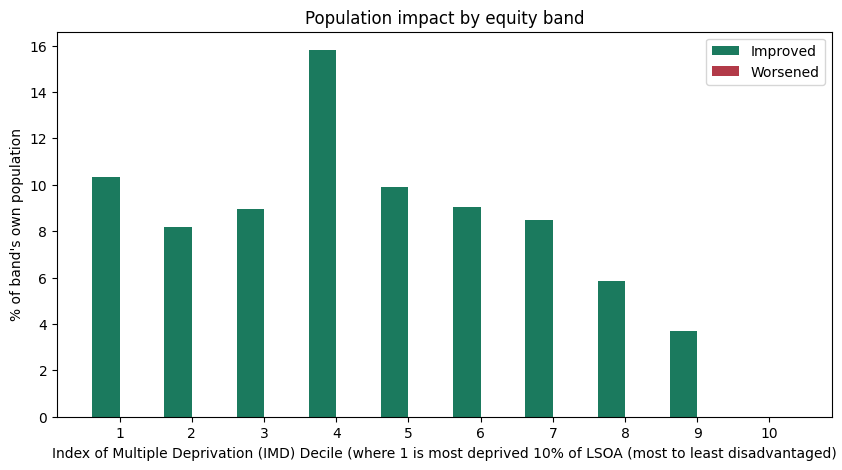

In [7]:
comparator.plot_population_impact_by_equity_group();

Now that equity data is registered, `population_impact_phrase()` automatically adds a rate-normalised sentence -- and would add a further clause about the most disadvantaged tertile getting worse journeys too, if that were ever non-zero.

In [8]:
print(comparator.population_impact_phrase())

46,907 people (9.0% of the cohort) get a shorter journey, averaging 16.1 minutes off. 61 of 729 regions improved; 0 worsened; 668 unchanged. In the most disadvantaged third of areas, 12.2% of people see a shorter journey, compared to 4.2% in the least disadvantaged third.


## Seeing the dilution

`SolutionComparator.plot_population_impact_summary()` plots the two numbers side by side: a small shift in the region-wide average sits on top of a real, concentrated local effect.

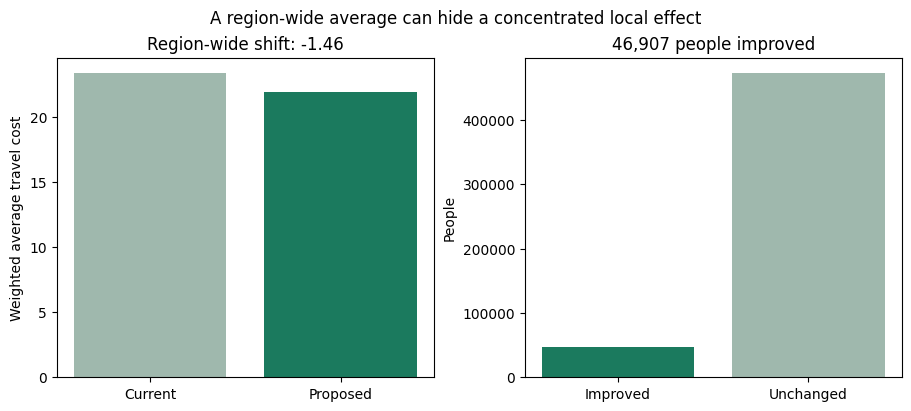

In [9]:
fig, axes = comparator.plot_population_impact_summary()
fig.savefig("image.png", dpi=150, bbox_inches="tight")

## The whole shape of the shift

The bar charts above answer "how many, how much" and "how did the average move" -- but they still collapse each LSOA down to a single improved/unchanged bucket. `plot_population_impact_histogram()` shows the full before/after distribution instead, weighted by population, with the two sides' weighted mean and maximum travel cost marked for reference.

By default it draws a smoothed kernel density estimate (`kind="kde"`) rather than a binned histogram, since two overlaid KDE curves are usually easier to compare by eye than two sets of overlapping bars -- pass `kind="hist"` for the traditional binned version instead.

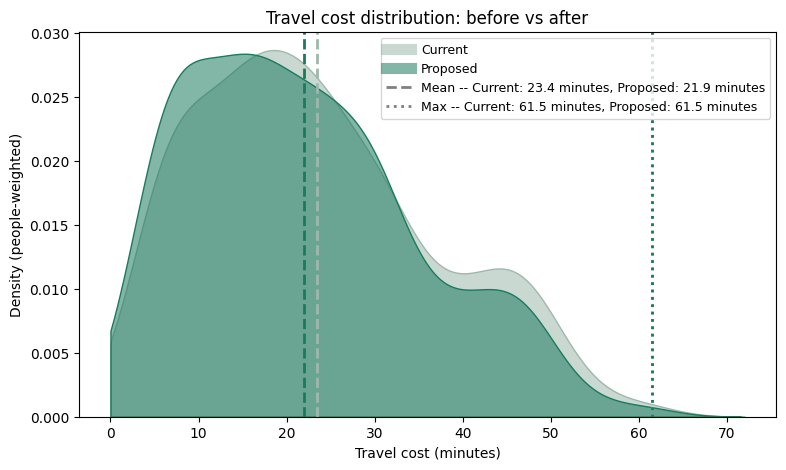

In [10]:
comparator.plot_population_impact_histogram();

## Who's left behind? Absolute headcounts beyond a threshold

`max` (the single worst-case travel time) is one data point -- it doesn't say how many people are in that tail, or whether a candidate touches them at all. `beyond_thresholds` reports the actual headcount beyond one or more cutoffs, alongside the existing `threshold_for_coverage` (which reports who's within a cutoff, the opposite direction).

These are nested/cumulative tiers, not independent buckets -- don't sum them.

In [11]:
import pandas as pd

baseline_bt = problem.evaluate_baseline(threshold_for_coverage=30, beyond_thresholds=[30, 45, 60])
candidate_bt = problem.evaluate_baseline(
    site_names=existing_sites + ["Barnstaple - Archwood Retail Park"],
    threshold_for_coverage=30,
    beyond_thresholds=[30, 45, 60],
    )

cols = ["demand_beyond_threshold_30", "demand_beyond_threshold_45", "demand_beyond_threshold_60"]
pd.DataFrame(
    {"Current": baseline_bt.solution_df.iloc[0][cols], "Proposed": candidate_bt.solution_df.iloc[0][cols]}
    )

,Current,Proposed
demand_beyond_threshold_30,148983.0,127670.0
demand_beyond_threshold_45,52145.0,39798.0
demand_beyond_threshold_60,2049.0,2049.0


The people beyond 30 or 45 minutes drop substantially -- but the >60-minute tier doesn't move at all. `max` alone would show this as "worst-case unchanged"; the headcount shows it as "this candidate does nothing for this specific group of people", which is the more policy-relevant framing.

## Every candidate at once, via `solve(baseline=...)`

Building and diffing one candidate at a time is fine for a single "what if we add this site?" question. To get the same columns automatically on every row of an enumerated `solve()`, pass the baseline in directly -- it's evaluated once, not once per candidate.

In [12]:
solutions = problem.solve(
    p=5,
    threshold_for_coverage=30,
    beyond_thresholds=[30, 45, 60],
    baseline=baseline,
    show_progress=False,
    )

solutions.show_solutions()[[
    "site_names",
    "weighted_average",
    "demand_improved",
    "demand_worsened",
    "mean_reduction_among_improved",
    "max_reduction",
    "demand_beyond_threshold_60",
    ]].head(5)

,site_names,weighted_average,demand_improved,demand_worsened,mean_reduction_among_improved,max_reduction,demand_beyond_threshold_60
0,"[Bideford Community Hospital, NHS Nightingale ...",21.93,46907.0,0.0,16.15,20.50,2049.0
1,"[Bideford Community Hospital, NHS Nightingale ...",22.05,41198.0,0.0,16.90,41.73,1107.0
2,"[Bideford Community Hospital, NHS Nightingale ...",22.15,71349.0,0.0,9.06,20.30,942.0
3,"[Bideford Community Hospital, NHS Nightingale ...",22.19,42894.0,0.0,14.56,29.75,2049.0
4,"[Bideford Community Hospital, NHS Nightingale ...",22.26,55123.0,0.0,10.70,27.10,2049.0


Every row above is scored against the same baseline, so `demand_improved`, `mean_reduction_among_improved`, and `demand_beyond_threshold_60` are directly comparable across candidates -- not just the region-wide `weighted_average` ranking.

From here, [comparing solutions](../comparing_solutions/index.ipynb) and [site allocation summaries](../comparing_n_sites/index.ipynb) are still useful for digging into *why* a particular candidate performs the way it does.